In [1]:
import numpy as np
import pandas as pd

In [2]:
class MatrixFactorization:

    def __init__(
        self,
        train_df,
        n_factors=20,
        learning_rate=0.01,
        regularization=0.02,
        epochs=20,
        random_state=42
    ):

        self.train_df = train_df

        self.n_factors = n_factors
        self.learning_rate = learning_rate
        self.regularization = regularization
        self.epochs = epochs

        np.random.seed(random_state)
        
        # ----------------------------------
        # User / Movie IDs
        # ----------------------------------

        self.users = train_df.user_id.unique()
        self.movies = train_df.movie_id.unique()

        self.num_users = len(self.users)
        self.num_movies = len(self.movies)

        self.user_to_idx = {
            user: idx
            for idx, user in enumerate(self.users)
        }

        self.movie_to_idx = {
            movie: idx
            for idx, movie in enumerate(self.movies)
        }

        self.idx_to_user = {
            idx: user
            for user, idx in self.user_to_idx.items()
        }

        self.idx_to_movie = {
            idx: movie
            for movie, idx in self.movie_to_idx.items()
        }
        
                # ----------------------------------
        # Global Mean
        # ----------------------------------

        self.global_mean = train_df.rating.mean()

        # ----------------------------------
        # User Embeddings
        # ----------------------------------

        self.P = np.random.normal(
            loc=0,
            scale=0.1,
            size=(self.num_users, self.n_factors)
        )

        # ----------------------------------
        # Movie Embeddings
        # ----------------------------------

        self.Q = np.random.normal(
            loc=0,
            scale=0.1,
            size=(self.num_movies, self.n_factors)
        )

        # ----------------------------------
        # Biases
        # ----------------------------------

        self.user_bias = np.zeros(self.num_users)

        self.movie_bias = np.zeros(self.num_movies)
        
        
    def predict(self,user_id,movie_id):

        if user_id not in self.user_to_idx:
            return self.global_mean

        if movie_id not in self.movie_to_idx:
            return self.global_mean

        u = self.user_to_idx[user_id]
        i = self.movie_to_idx[movie_id]

        prediction = (
            self.global_mean
            + self.user_bias[u]
            + self.movie_bias[i]
            + np.dot(
                self.P[u],
                self.Q[i]
            )
        )

        prediction = np.clip(prediction,1,5)

        return float(prediction)
    
    
    def fit(self):

        print("Training Matrix Factorization...")
    
        for epoch in range(self.epochs):
        
            squared_error = 0.0
    
            # Shuffle training data every epoch
            train_shuffled = self.train_df.sample(
                frac=1,
                random_state=epoch
            )
    
            for row in train_shuffled.itertuples(index=False):
            
                user = row.user_id
                movie = row.movie_id
                rating = row.rating
    
                # Convert IDs to indices
                u = self.user_to_idx[user]
                i = self.movie_to_idx[movie]
    
                # -------------------------------
                # Prediction
                # -------------------------------
                prediction = (
                    self.global_mean
                    + self.user_bias[u]
                    + self.movie_bias[i]
                    + np.dot(
                        self.P[u],
                        self.Q[i]
                    )
                )
    
                # -------------------------------
                # Error
                # -------------------------------
                error = rating - prediction
    
                squared_error += error ** 2
    
                # -------------------------------
                # Store old vectors
                # (Important!)
                # -------------------------------
                user_vector = self.P[u].copy()
                movie_vector = self.Q[i].copy()
    
                # -------------------------------
                # Update User Bias
                # -------------------------------
                self.user_bias[u] += (
                    self.learning_rate
                    * (
                        error
                        - self.regularization
                        * self.user_bias[u]
                    )
                )
    
                # -------------------------------
                # Update Movie Bias
                # -------------------------------
                self.movie_bias[i] += (
                    self.learning_rate
                    * (
                        error
                        - self.regularization
                        * self.movie_bias[i]
                    )
                )
    
                # -------------------------------
                # Update User Latent Vector
                # -------------------------------
                self.P[u] += (
                    self.learning_rate
                    * (
                        error * movie_vector
                        - self.regularization
                        * user_vector
                    )
                )
    
                # -------------------------------
                # Update Movie Latent Vector
                # -------------------------------
                self.Q[i] += (
                    self.learning_rate
                    * (
                        error * user_vector
                        - self.regularization
                        * movie_vector
                    )
                )
    
            # -------------------------------
            # Epoch RMSE
            # -------------------------------
            rmse = np.sqrt(
                squared_error /
                len(self.train_df)
            )
    
            print(
                f"Epoch {epoch+1:2d}/{self.epochs} | RMSE = {rmse:.4f}"
            )
            
            
    def recommend(
        self,
        user_id,
        top_n=10
    ):
    
        watched_movies = set(
            self.train_df[
                self.train_df.user_id == user_id
            ].movie_id
        )
    
        recommendations = []
    
        for movie in self.movies:
        
            if movie in watched_movies:
                continue
            
            prediction = self.predict(
                user_id,
                movie
            )
    
            recommendations.append(
                (
                    movie,
                    prediction
                )
            )
    
        recommendations.sort(
            key=lambda x: x[1],
            reverse=True
        )
    
        return pd.DataFrame(
            recommendations[:top_n],
            columns=[
                "movie_id",
                "predicted_rating"
            ]
        )
        
    def evaluate(
        self,
        test_df
    ):
    
        predictions = []
    
        squared_errors = []
    
        absolute_errors = []
    
        for row in test_df.itertuples(index=False):
        
            prediction = self.predict(
                row.user_id,
                row.movie_id
            )
    
            error = abs(
                row.rating - prediction
            )
    
            predictions.append(
                (
                    row.user_id,
                    row.movie_id,
                    row.rating,
                    prediction,
                    error
                )
            )
    
            absolute_errors.append(error)
    
            squared_errors.append(error ** 2)
    
        prediction_df = pd.DataFrame(
            predictions,
            columns=[
                "user_id",
                "movie_id",
                "actual",
                "predicted",
                "error"
            ]
        )
    
        mae = np.mean(
            absolute_errors
        )
    
        rmse = np.sqrt(
            np.mean(
                squared_errors
            )
        )
    
        return prediction_df, rmse, mae

In [3]:
train = pd.read_csv(
    "data/u1.base",
    sep="\t",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

test = pd.read_csv(
    "data/u1.test",
    sep="\t",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

In [4]:
mf = MatrixFactorization(
    train,
    n_factors=20,
    learning_rate=0.01,
    regularization=0.02,
    epochs=20
)

mf.fit()

Training Matrix Factorization...
Epoch  1/20 | RMSE = 1.0162
Epoch  2/20 | RMSE = 0.9536
Epoch  3/20 | RMSE = 0.9353
Epoch  4/20 | RMSE = 0.9247
Epoch  5/20 | RMSE = 0.9167
Epoch  6/20 | RMSE = 0.9093
Epoch  7/20 | RMSE = 0.9020
Epoch  8/20 | RMSE = 0.8932
Epoch  9/20 | RMSE = 0.8832
Epoch 10/20 | RMSE = 0.8715
Epoch 11/20 | RMSE = 0.8580
Epoch 12/20 | RMSE = 0.8434
Epoch 13/20 | RMSE = 0.8282
Epoch 14/20 | RMSE = 0.8127
Epoch 15/20 | RMSE = 0.7972
Epoch 16/20 | RMSE = 0.7823
Epoch 17/20 | RMSE = 0.7679
Epoch 18/20 | RMSE = 0.7542
Epoch 19/20 | RMSE = 0.7413
Epoch 20/20 | RMSE = 0.7295


In [5]:
prediction_df, rmse, mae = mf.evaluate(test)

print("MAE :", mae)
print("RMSE:", rmse)

MAE : 0.7446229393193023
RMSE: 0.954026328353859


In [6]:
mf.recommend(1, top_n=10)

,movie_id,predicted_rating
0,174,5.000000
1,64,5.000000
2,511,5.000000
3,170,4.990079
4,100,4.950500
5,435,4.923084
6,69,4.897855
7,1142,4.890751
8,262,4.879150
9,527,4.778354


In [7]:
mf.P.shape,mf.Q.shape

((943, 20), (1650, 20))

In [8]:
np.dot(mf.P, mf.Q.T).shape  

(943, 1650)

In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [12]:
pca = PCA(n_components=2)

movie_embeddings_2d = pca.fit_transform(
    mf.Q
)

In [13]:
movie_embeddings_2d.shape

(1650, 2)

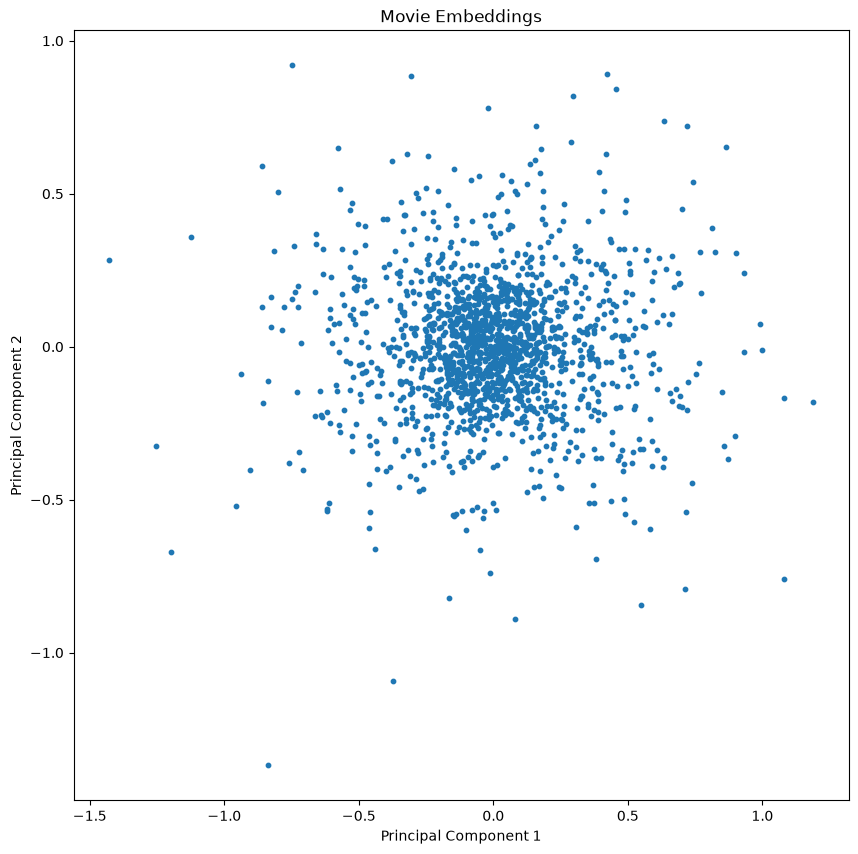

In [14]:
plt.figure(figsize=(10,10))

plt.scatter(
    movie_embeddings_2d[:,0],
    movie_embeddings_2d[:,1],
    s=10
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("Movie Embeddings")

plt.show()

In [16]:
users= pd.read_csv(
    "data/u.user",
    sep="|",
    encoding="latin-1",
    header=None,
)
users.columns = ["user_id", "age", "gender", "occupation", "zip_code"]
users.head()

,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


In [18]:
ratings = pd.read_csv(
    "data/u.data",
    sep="\t",
    names=["user_id", "movie_id", "rating", "timestamp"]
)
ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [19]:
movies = pd.read_csv(
    "data/u.item",
    sep="|",
    encoding="latin-1",
    header=None
)
movie_columns = [
    "movie_id",
    "title",
    "release_date",
    "video_release_date",
    "imdb_url",
    "unknown",
    "action",
    "adventure",
    "animation",
    "children",
    "comedy",
    "crime",
    "documentary",
    "drama",
    "fantasy",
    "film_noir",
    "horror",
    "musical",
    "mystery",
    "romance",
    "sci_fi",
    "thriller",
    "war",
    "western"
]

movies.columns = movie_columns

movies.head()

,movie_id,title,release_date,video_release_date,imdb_url,unknown,action,adventure,animation,children,...,fantasy,film_noir,horror,musical,mystery,romance,sci_fi,thriller,war,western
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [20]:
movie_lookup = movies.set_index(
    "movie_id"
)["title"]

In [21]:
famous = [
    1,
    50,
    100,
    181,
    258,
    300,
    174,
    121,
    172,
    222
]

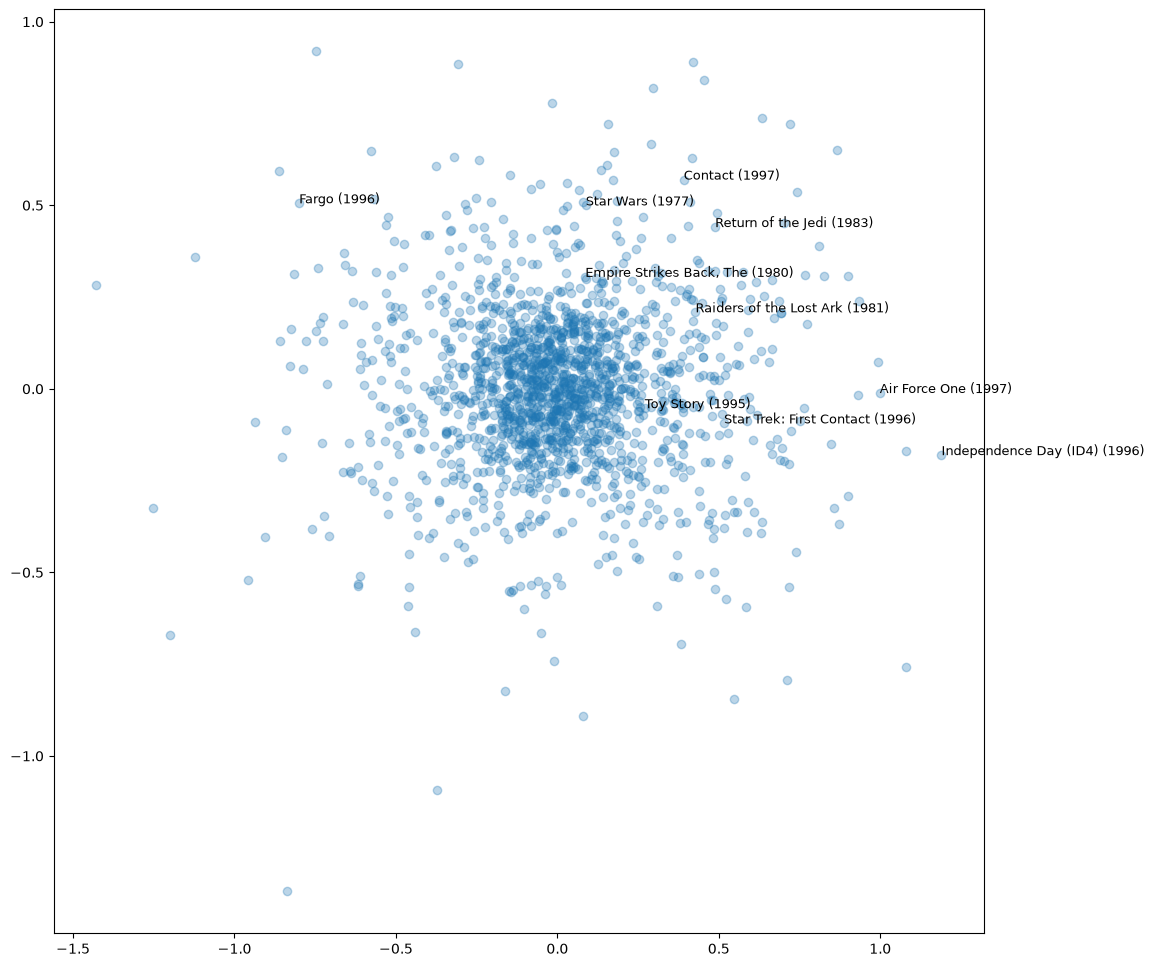

In [22]:
plt.figure(figsize=(12,12))

plt.scatter(
    movie_embeddings_2d[:,0],
    movie_embeddings_2d[:,1],
    alpha=0.3
)

for movie in famous:

    if movie not in mf.movie_to_idx:
        continue

    idx = mf.movie_to_idx[movie]

    x = movie_embeddings_2d[idx,0]
    y = movie_embeddings_2d[idx,1]

    plt.text(
        x,
        y,
        movie_lookup[movie],
        fontsize=9
    )

plt.show()

In [23]:
from sklearn.manifold import TSNE

In [24]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

movie_embeddings_2d = tsne.fit_transform(
    mf.Q
)

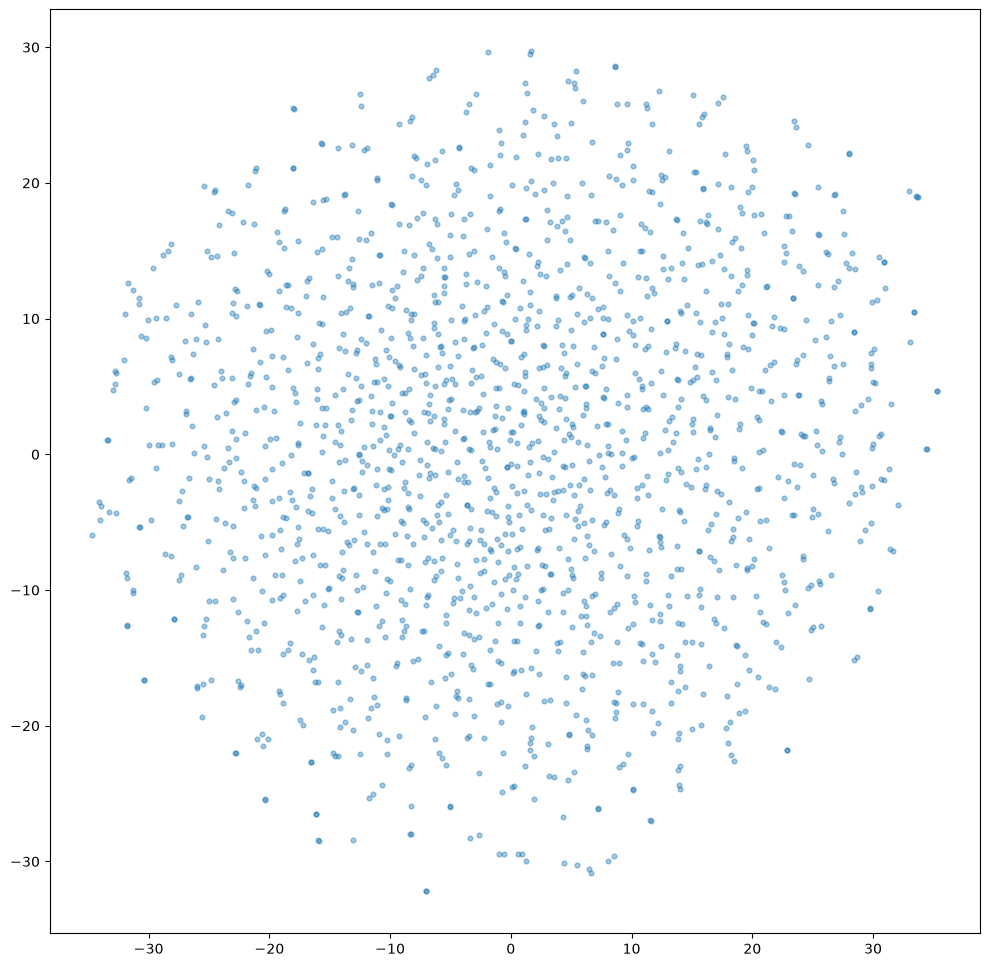

In [25]:
plt.figure(figsize=(12,12))

plt.scatter(
    movie_embeddings_2d[:,0],
    movie_embeddings_2d[:,1],
    s=12,
    alpha=0.4
)

plt.show()

In [26]:
interesting_movies = [
    "Toy Story (1995)",
    "Star Wars (1977)",
    "Raiders of the Lost Ark (1981)",
    "Titanic (1997)",
    "Fargo (1996)",
    "Alien (1979)",
    "Aliens (1986)",
    "Matrix, The (1999)",
    "Terminator 2: Judgment Day (1991)",
    "Shawshank Redemption, The (1994)"
]

In [27]:
interesting = movies[
    movies["title"].isin(
        interesting_movies
    )
]

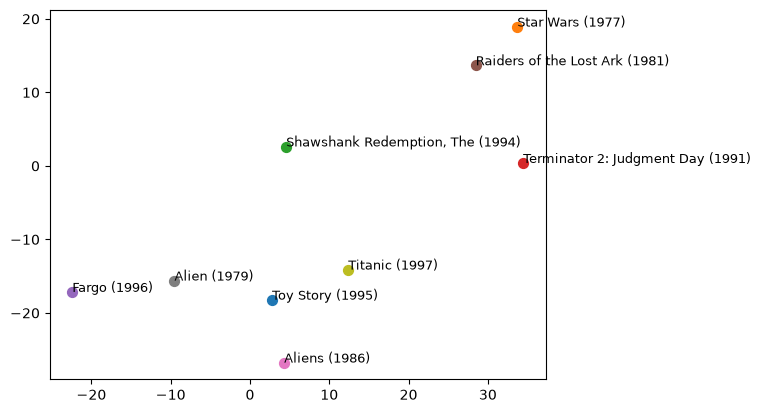

In [28]:
for _, row in interesting.iterrows():

    movie_id = row.movie_id

    if movie_id not in mf.movie_to_idx:
        continue

    idx = mf.movie_to_idx[movie_id]

    x = movie_embeddings_2d[idx,0]
    y = movie_embeddings_2d[idx,1]

    plt.scatter(
        x,
        y,
        s=50
    )

    plt.text(
        x,
        y,
        row.title,
        fontsize=9
    )